In [4]:
import requests
import numpy as np

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

C:\Users\domen\AppData\Local\Temp\ipykernel_5900\1731147669.py:10: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [5]:
print("Contenuto di names:", names)

Contenuto di names: ['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']


C:\Users\domen\AppData\Local\Temp\ipykernel_5900\1270950880.py:12: RuntimeWarning: invalid value encountered in log10
  ax1.hist(np.log10(T90[~np.isnan(T90)]), bins=30, alpha=0.7)


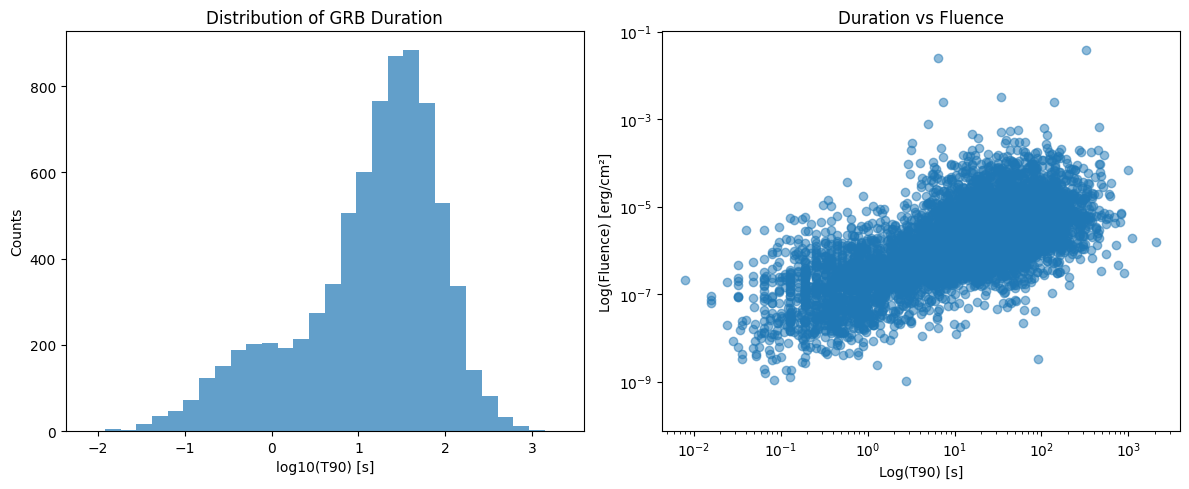

Number of GRBs: 8724
Number of GRBs with valid T90: 8724


In [6]:
import matplotlib.pyplot as plt

# Converti i dati in float dove possibile, ignorando i valori non numerici
T90 = np.array([float(x) if x != '-' else np.nan for x in data[np.where(names == 'T90')[0][0]]])
Fluence = np.array([float(x) if x != '-' else np.nan for x in data[np.where(names == 'fluence')[0][0]]])


# Crea una figura con due subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Distribuzione di T90 (scala logaritmica)
ax1.hist(np.log10(T90[~np.isnan(T90)]), bins=30, alpha=0.7)
ax1.set_xlabel('log10(T90) [s]')
ax1.set_ylabel('Counts')
ax1.set_title('Distribution of GRB Duration')

# Plot 2: T90 vs Fluence (scatter plot)
ax2.scatter(T90[~np.isnan(T90)], 
           Fluence[~np.isnan(Fluence)], 
           alpha=0.5)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xlabel('Log(T90) [s]')
ax2.set_ylabel('Log(Fluence) [erg/cm²]')
ax2.set_title('Duration vs Fluence')

plt.tight_layout()
plt.show()

# Stampa alcune statistiche
print("Number of GRBs:", len(T90))
print("Number of GRBs with valid T90:", np.sum(~np.isnan(T90)))

In [11]:
# Crea le mask per dati validi
mask_T90 = ~np.isnan(T90) & (T90 != -999)
mask_Fluence = ~np.isnan(Fluence) & (Fluence != -999)

# Combina le mask per avere solo righe con entrambi i valori validi
mask_total = mask_T90 & mask_Fluence

# Applica la mask ai dati
T90_clean = T90[mask_total]
Fluence_clean = Fluence[mask_total]
X = np.column_stack([T90_clean, Fluence_clean]) 

Text(0.5, 1.0, 'Duration vs Fluence')

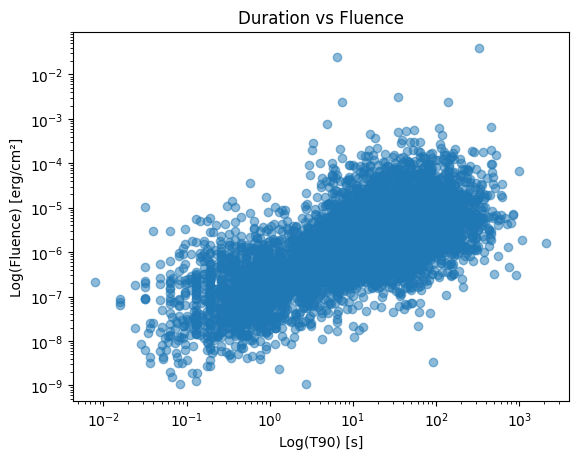

In [12]:
plt.scatter(T90_clean, 
           Fluence_clean, 
           alpha=0.5)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Log(T90) [s]')
plt.ylabel('Log(Fluence) [erg/cm²]')
plt.title('Duration vs Fluence')

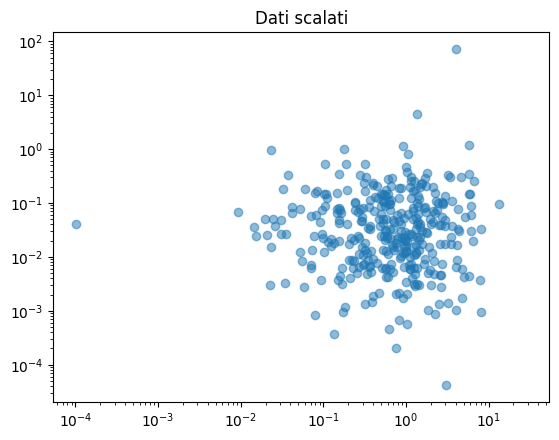

In [29]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)  # QUI avviene il vero scaling

plt.scatter(X_scaled[:,0], X_scaled[:,1], alpha=0.5)
plt.title("Dati scalati")
plt.xscale('log')
plt.yscale('log')

plt.show()

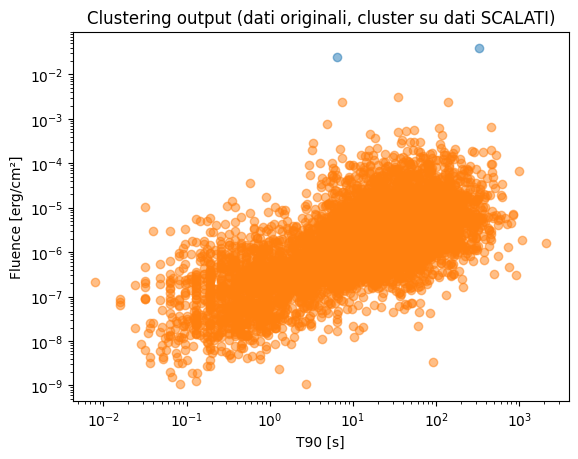

In [37]:
from sklearn.cluster import KMeans
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)  # QUI avviene il vero scaling

clf = KMeans(n_clusters=2, n_init='auto')
clf.fit(X_scaled)
labels = clf.predict(X_scaled)

# Plot: attenzione, se vuoi vedere i cluster sui dati originali va bene plottare X, 
# ma usa sempre labels generati da fit/predict sui dati SCALATI.
colors = ['C1', 'C0']
for ii in range(2):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], color=colors[ii], alpha=0.5)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('T90 [s]')
plt.ylabel('Fluence [erg/cm²]')
plt.title('Clustering output (dati originali, cluster su dati SCALATI)')
plt.show()
